In [1]:
# install.packages('cowplot')

In [2]:
# if (!require("BiocManager", quietly = TRUE))
#     install.packages("BiocManager")

# BiocManager::install("qvalue")

In [3]:
#Code adpated from the STAR package https://github.com/xihaoli/STAAR/blob/dc4f7e509f4fa2fb8594de48662bbd06a163108c/R/CCT.R wtih a modifitcaiton: when indiviudal p-value = 1, use minimum p-value 
#' An analytical p-value combination method using the Cauchy distribution
#'
#' The \code{CCT} function takes in a numeric vector of p-values, a numeric
#' vector of non-negative weights, and return the aggregated p-value using Cauchy method.
#' @param pvals a numeric vector of p-values, where each of the element is
#' between 0 to 1, to be combined.
#' @param weights a numeric vector of non-negative weights. If \code{NULL}, the
#' equal weights are assumed.
#' @return the aggregated p-value combining p-values from the vector \code{pvals}.
#' @examples pvalues <- c(2e-02,4e-04,0.2,0.1,0.8)
#' @examples CCT(pvals=pvalues)
#' @references Liu, Y., & Xie, J. (2020). Cauchy combination test: a powerful test
#' with analytic p-value calculation under arbitrary dependency structures.
#' \emph{Journal of the American Statistical Association 115}(529), 393-402.
#' (\href{https://www.tandfonline.com/doi/full/10.1080/01621459.2018.1554485}{pub})
#' @export

CCT <- function(pvals, weights=NULL){
  #### check if there is NA
  if(sum(is.na(pvals)) > 0){
    stop("Cannot have NAs in the p-values!")
  }

  #### check if all p-values are between 0 and 1
  if((sum(pvals<0) + sum(pvals>1)) > 0){
    stop("All p-values must be between 0 and 1!")
  }

  #### check if there are p-values that are either exactly 0 or 1.
  is.zero <- (sum(pvals==0)>=1)
  is.one <- (sum(pvals==1)>=1)
  #if(is.zero && is.one){
  #  stop("Cannot have both 0 and 1 p-values!")
  #}
  if(is.zero){
    return(0)
  }
  if(is.one){
    #warning("There are p-values that are exactly 1!")
    return(min(1,(min(pvals))*(length(pvals))))
  }

  #### check the validity of weights (default: equal weights) and standardize them.
  if(is.null(weights)){
    weights <- rep(1/length(pvals),length(pvals))
  }else if(length(weights)!=length(pvals)){
    stop("The length of weights should be the same as that of the p-values!")
  }else if(sum(weights < 0) > 0){
    stop("All the weights must be positive!")
  }else{
    weights <- weights/sum(weights)
  }

  #### check if there are very small non-zero p-values
  is.small <- (pvals < 1e-16)
  if (sum(is.small) == 0){
    cct.stat <- sum(weights*tan((0.5-pvals)*pi))
  }else{
    cct.stat <- sum((weights[is.small]/pvals[is.small])/pi)
    cct.stat <- cct.stat + sum(weights[!is.small]*tan((0.5-pvals[!is.small])*pi))
  }

  #### check if the test statistic is very large.
  if(cct.stat > 1e+15){
    pval <- (1/cct.stat)/pi
  }else{
    pval <- 1-pcauchy(cct.stat)
  }
  return(pval)
}

In [4]:
get_CCT_pvalue = function(pvalue, weights=NULL){
   pvals = pvalue
   notna = which(!is.na(pvals))
   if(length(notna) > 0){
     pvals = pvals[!is.na(pvals)]
     cctpval = CCT(pvals, weights=weights)
   }else{
     cctpval = NA
   }
   return(cctpval)
}

In [28]:
library(cowplot)
library(data.table)
library(ggplot2)
library(qvalue)

In [29]:
saige_dir = '/directflow/SCCGGroupShare/projects/anncuo/TenK10K_pilot/tenk10k/eqtl_results/saige_qtl/december24_freeze/'
celltypes = list.files(saige_dir)
celltypes = celltypes[!(celltypes %in% c('README.md','CD4_TCM_sample_perm0','annotate','coloc_results'))]
length(celltypes)
celltypes

[1] 28

[1] "ASDC"              "B_intermediate"    "B_memory"         
 [4] "B_naive"           "CD14_Mono"         "CD16_Mono"        
 [7] "CD4_CTL"           "CD4_Naive"         "CD4_Proliferating"
[10] "CD4_TCM"           "CD4_TEM"           "CD8_Naive"        
[13] "CD8_Proliferating" "CD8_TCM"           "CD8_TEM"          
[16] "cDC1"              "cDC2"              "dnT"              
[19] "gdT"               "HSPC"              "ILC"              
[22] "MAIT"              "NK"                "NK_CD56bright"    
[25] "NK_Proliferating"  "pDC"               "Plasmablast"      
[28] "Treg"

In [46]:
df_list = list()
for (celltype in celltypes){
    rare_set_file = paste0(saige_dir,celltype,'/',celltype,'_all_cis_rv_set_test_results.tsv')
    rare_set_df = as.data.frame(fread(rare_set_file))
    df = rare_set_df[rare_set_df$Group == "Cauchy",]
    df <- df[rowSums(is.na(df)) != ncol(df), ]
#     df$celltype = celltype
    for (i in 1:nrow(df)){
        df[i,'Pvalue_noACAT'] = get_CCT_pvalue(c(df[i,'Pvalue_Burden'], df[i,'Pvalue_SKAT']))
    }
    df$qvalue = qvalue(df$Pvalue_noACAT)$qvalues
    df$qvalue_Burden = qvalue(df$Pvalue_Burden)$qvalues
    df$qvalue_SKAT = qvalue(df$Pvalue_SKAT)$qvalues
    rare_egenes = df[df$qvalue<0.05,]$Region
#     nonrare_egenes = df$Region[!(df$Region %in% rare_egenes)]
    burden_egenes = df[df$qvalue_Burden<0.05,]$Region
#     burden_egenes = burden_egenes[burden_egenes %in% rare_egenes]
    skat_egenes = df[df$qvalue_SKAT<0.05,]$Region
    skat_egenes = skat_egenes[skat_egenes %in% rare_egenes]
    burden_only_egenes = burden_egenes[!(burden_egenes %in% skat_egenes)]
#     burden_and_skat_egenes = skat_egenes[skat_egenes %in% burden_egenes]
    skat_only_egenes = skat_egenes[!(skat_egenes %in% burden_egenes)]
    burden_and_skat_egenes = rare_egenes[!(rare_egenes %in% c(skat_only_egenes,burden_only_egenes))]
    df_cur = data.frame(celltype = celltype,
                        test = c('Burden_only','SKAT_and_Burden','SKAT_only'),
                        n = c(length(burden_only_egenes), length(burden_and_skat_egenes), length(skat_only_egenes)))
    df_cur$prop = df_cur$n / length(rare_egenes)
    df_list[[celltype]] = df_cur
}
df_to_plot = rbindlist(df_list)
nrow(df_to_plot)
head(df_to_plot,2)

[1] 84

celltype,test,n,prop
<chr>,<chr>,<int>,<dbl>
ASDC,Burden_only,1,0.01639344
ASDC,SKAT_and_Burden,13,0.21311475


In [47]:
burden_tot = sum(df_to_plot[df_to_plot$test == 'Burden_only',]$n)
skat_tot = sum(df_to_plot[df_to_plot$test == 'SKAT_only',]$n)
both_tot = sum(df_to_plot[df_to_plot$test == 'SKAT_and_Burden',]$n)

In [48]:
c(burden_tot, skat_tot, both_tot, sum(c(burden_tot, skat_tot, both_tot)))
c(burden_tot/sum(c(burden_tot, skat_tot, both_tot)),
 skat_tot/sum(c(burden_tot, skat_tot, both_tot)),
 both_tot/sum(c(burden_tot, skat_tot, both_tot)))
burden_tot/sum(c(burden_tot, skat_tot, both_tot))*100

[1]   141 29260  4975 34376

[1] 0.004101699 0.851175239 0.144723063

[1] 0.4101699

In [49]:
# df_to_plot

In [50]:
df_to_plot=as.data.frame(df_to_plot)
df_to_plot$prop_nonskat = df_to_plot$prop
for (celltype in unique(df_to_plot$celltype)){
    df_cur = df_to_plot[df_to_plot$celltype == celltype,]
    n = sum(df_cur[df_cur$test != 'SKAT_only',]$prop)
    df_to_plot[df_to_plot$celltype == celltype,]$prop_nonskat = n
}

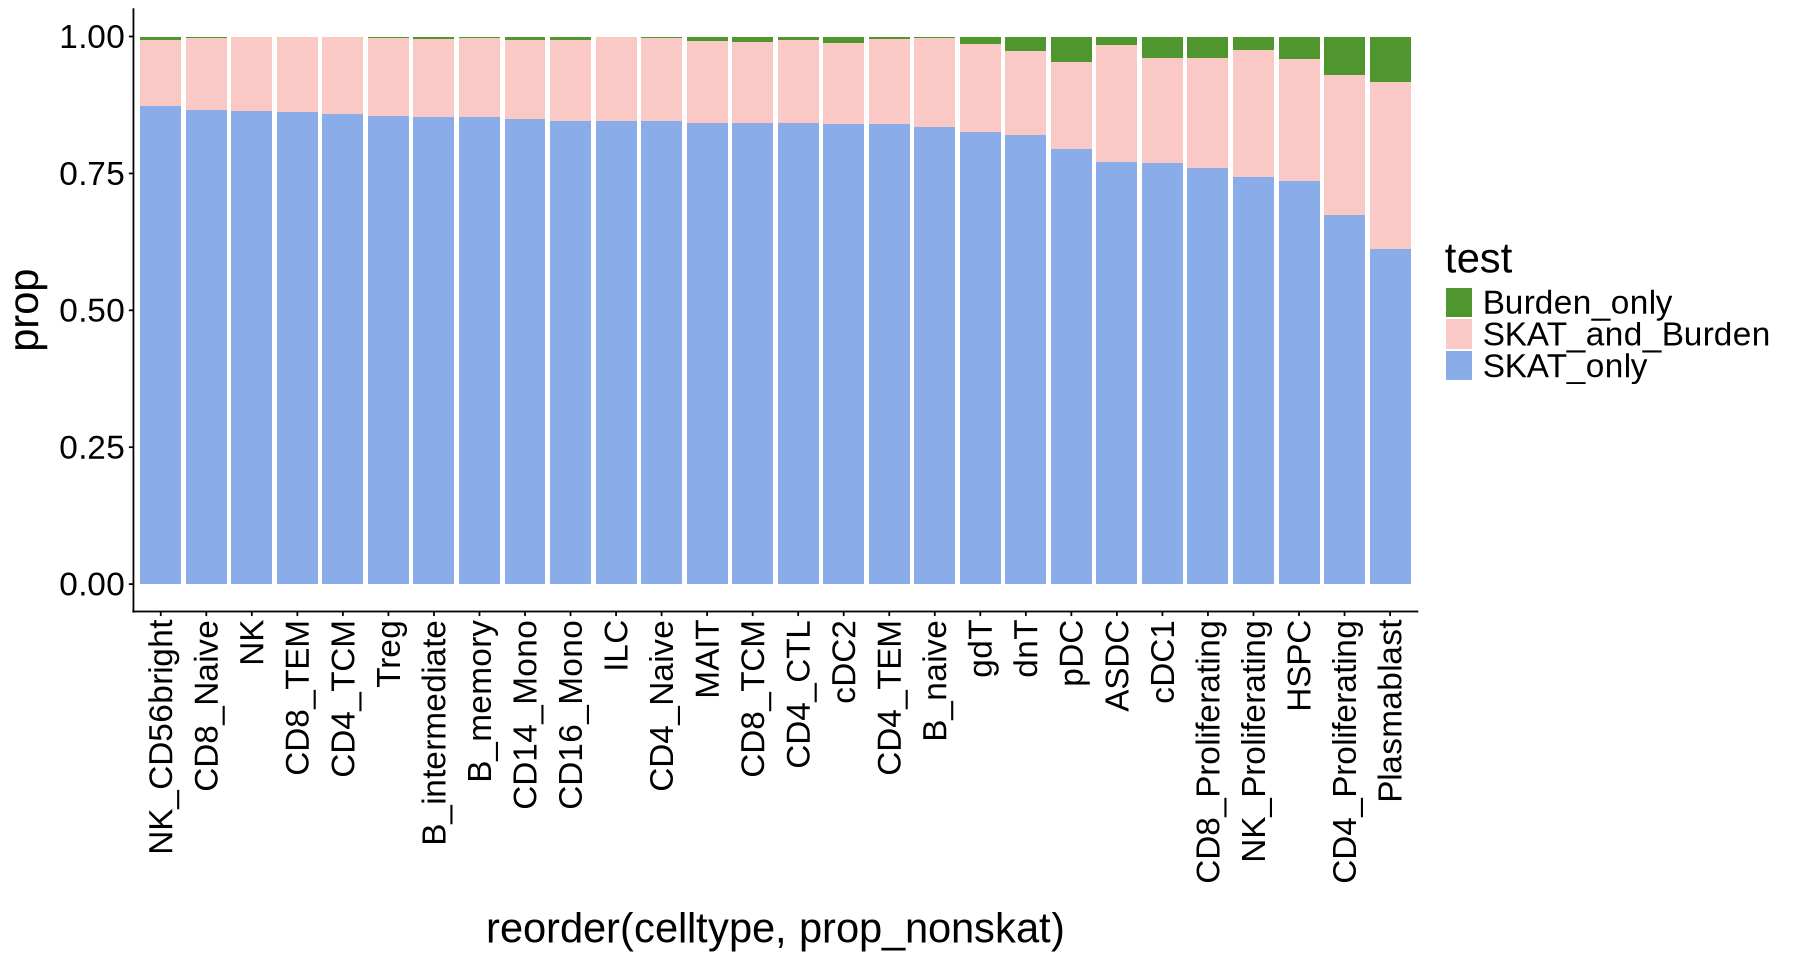

In [56]:
options(repr.plot.width = 15, repr.plot.height = 8)
p = ggplot(df_to_plot, aes(x=reorder(celltype,prop_nonskat),y=prop,fill=test)) + geom_bar(stat='identity')
# p = p + scale_fill_brewer(palette = "Set1") + theme_classic() 
p = p + scale_fill_manual(values = c('#50962E','#FAC8C5','#8AADEA')) + theme_classic() 
p = p + theme(text = element_text(size=25), axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1),)
p

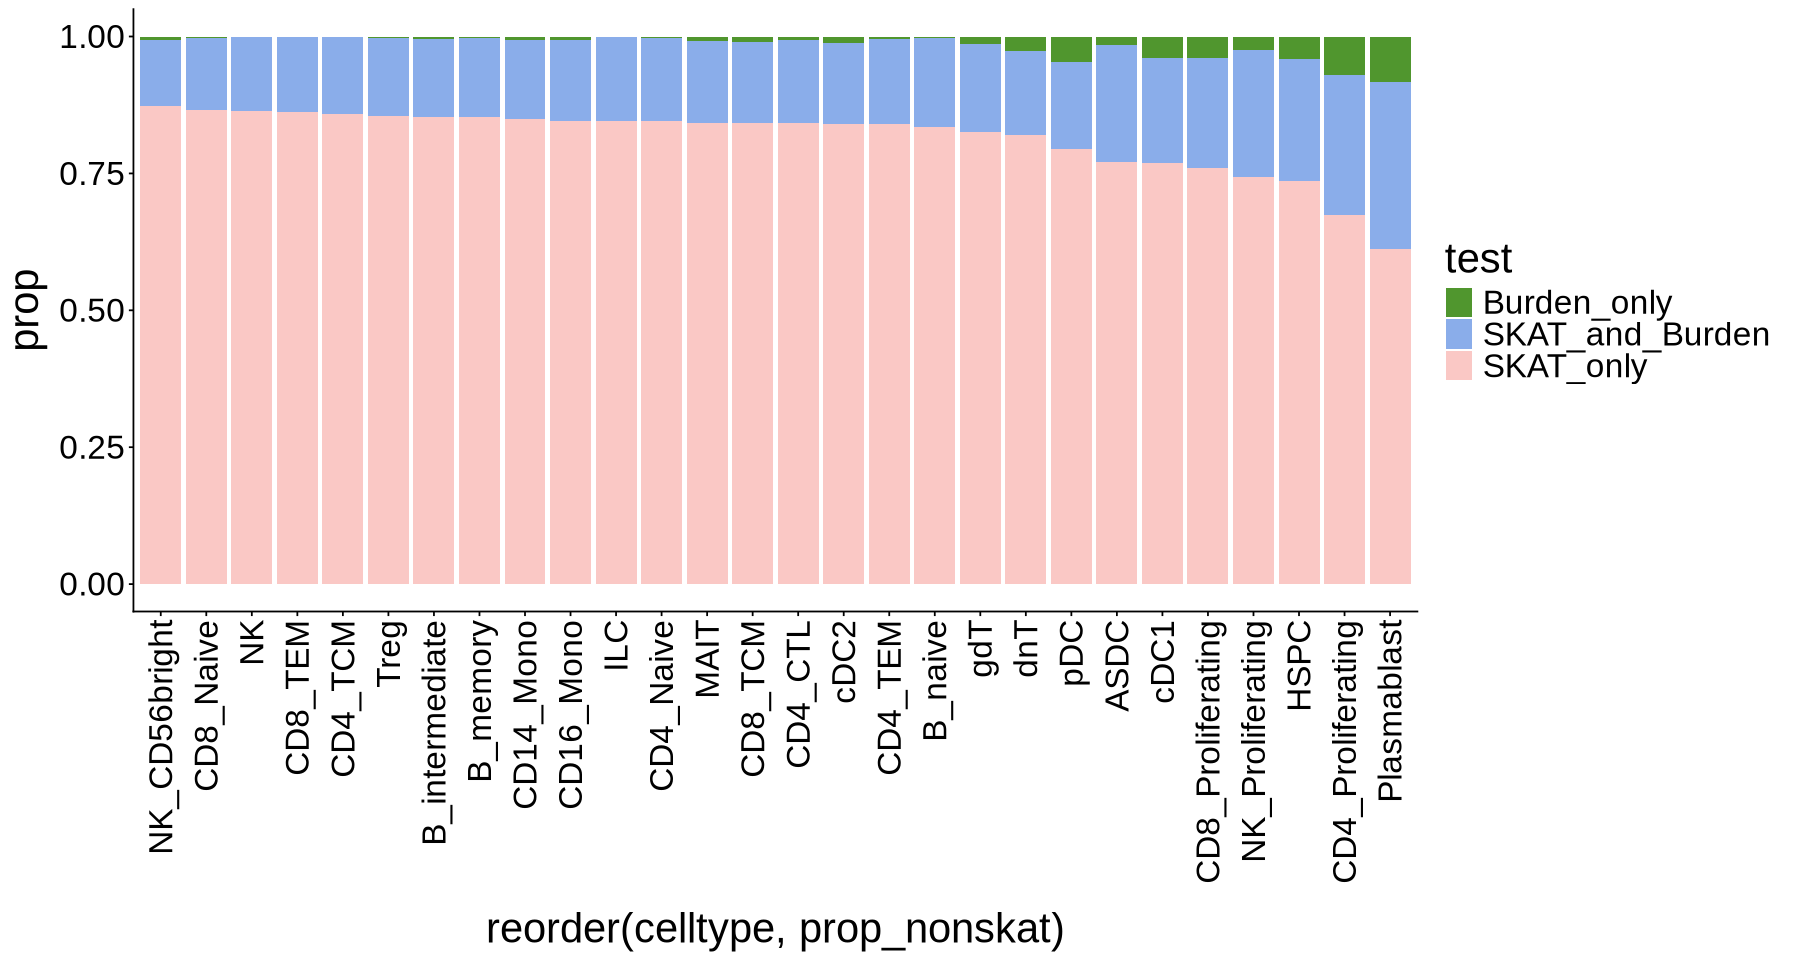

In [55]:
options(repr.plot.width = 15, repr.plot.height = 8)
p = ggplot(df_to_plot, aes(x=reorder(celltype,prop_nonskat),y=prop,fill=test)) + geom_bar(stat='identity')
# p = p + scale_fill_brewer(palette = "Set1") + theme_classic() 
p = p + scale_fill_manual(values = c('#50962E','#8AADEA','#FAC8C5')) + theme_classic() 
p = p + theme(text = element_text(size=25), axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1),)
p

In [21]:
disease_genes_dir = '/directflow/SCCGGroupShare/projects/anncuo/TenK10K_pilot/tenk10k/review_files/disease_gene_lists/'
list.files(disease_genes_dir)

[1] "gene_fulltable.txt" "Incidentalome.tsv"  "Mendeliome.tsv"

In [22]:
df_genes1 = as.data.frame(fread(paste0(disease_genes_dir,'Mendeliome.tsv')))
genes1 = unique(df_genes1[['EnsemblId(GRch38)']])
df_genes2 = as.data.frame(fread(paste0(disease_genes_dir,'Incidentalome.tsv')))
genes2 = unique(df_genes2[['EnsemblId(GRch38)']])
all_disease_genes = unique(c(genes1,genes2))
length(all_disease_genes)

[1] 4290

In [23]:
df_list = list()
for (celltype in celltypes){
    rare_set_file = paste0(saige_dir,celltype,'/',celltype,'_all_cis_rv_set_test_results.tsv')
    rare_set_df = as.data.frame(fread(rare_set_file))
    df = rare_set_df[rare_set_df$Group == "Cauchy",]
    df <- df[rowSums(is.na(df)) != ncol(df), ]
    df = df[df$Region %in% all_disease_genes,]
    for (i in 1:nrow(df)){
        df[i,'Pvalue_noACAT'] = get_CCT_pvalue(c(df[i,'Pvalue_Burden'], df[i,'Pvalue_SKAT']))
    }
    df$qvalue = qvalue(df$Pvalue_noACAT)$qvalues
    df$qvalue_Burden = qvalue(df$Pvalue_Burden)$qvalues
    df$qvalue_SKAT = qvalue(df$Pvalue_SKAT)$qvalues
    rare_egenes = df[df$qvalue<0.05,]$Region
#     nonrare_egenes = df$Region[!(df$Region %in% rare_egenes)]
    burden_egenes = df[df$qvalue_Burden<0.05,]$Region
#     burden_egenes = burden_egenes[burden_egenes %in% rare_egenes]
    skat_egenes = df[df$qvalue_SKAT<0.05,]$Region
    skat_egenes = skat_egenes[skat_egenes %in% rare_egenes]
    burden_only_egenes = burden_egenes[!(burden_egenes %in% skat_egenes)]
#     burden_and_skat_egenes = skat_egenes[skat_egenes %in% burden_egenes]
    skat_only_egenes = skat_egenes[!(skat_egenes %in% burden_egenes)]
    burden_and_skat_egenes = rare_egenes[!(rare_egenes %in% c(skat_only_egenes,burden_only_egenes))]
    df_cur = data.frame(celltype = celltype,
                        test = c('Burden_only','Burden_and_SKAT','SKAT_only'),
                        n = c(length(burden_only_egenes), length(burden_and_skat_egenes), length(skat_only_egenes)))
    df_cur$prop = df_cur$n / length(rare_egenes)
    df_list[[celltype]] = df_cur
}
df_to_plot = rbindlist(df_list)
nrow(df_to_plot)
head(df_to_plot,2)

[1] 84

celltype,test,n,prop
<chr>,<chr>,<int>,<dbl>
ASDC,Burden_only,0,0.00
ASDC,Burden_and_SKAT,2,0.25


In [25]:
burden_tot = sum(df_to_plot[df_to_plot$test == 'Burden_only',]$n)
skat_tot = sum(df_to_plot[df_to_plot$test == 'SKAT_only',]$n)
both_tot = sum(df_to_plot[df_to_plot$test == 'Burden_and_SKAT',]$n)

In [26]:
c(burden_tot, skat_tot, both_tot, sum(c(burden_tot, skat_tot, both_tot)))
c(burden_tot/sum(c(burden_tot, skat_tot, both_tot)),
 skat_tot/sum(c(burden_tot, skat_tot, both_tot)),
 both_tot/sum(c(burden_tot, skat_tot, both_tot)))
burden_tot/sum(c(burden_tot, skat_tot, both_tot))*100

[1]   17 4875  633 5525

[1] 0.003076923 0.882352941 0.114570136

[1] 0.3076923

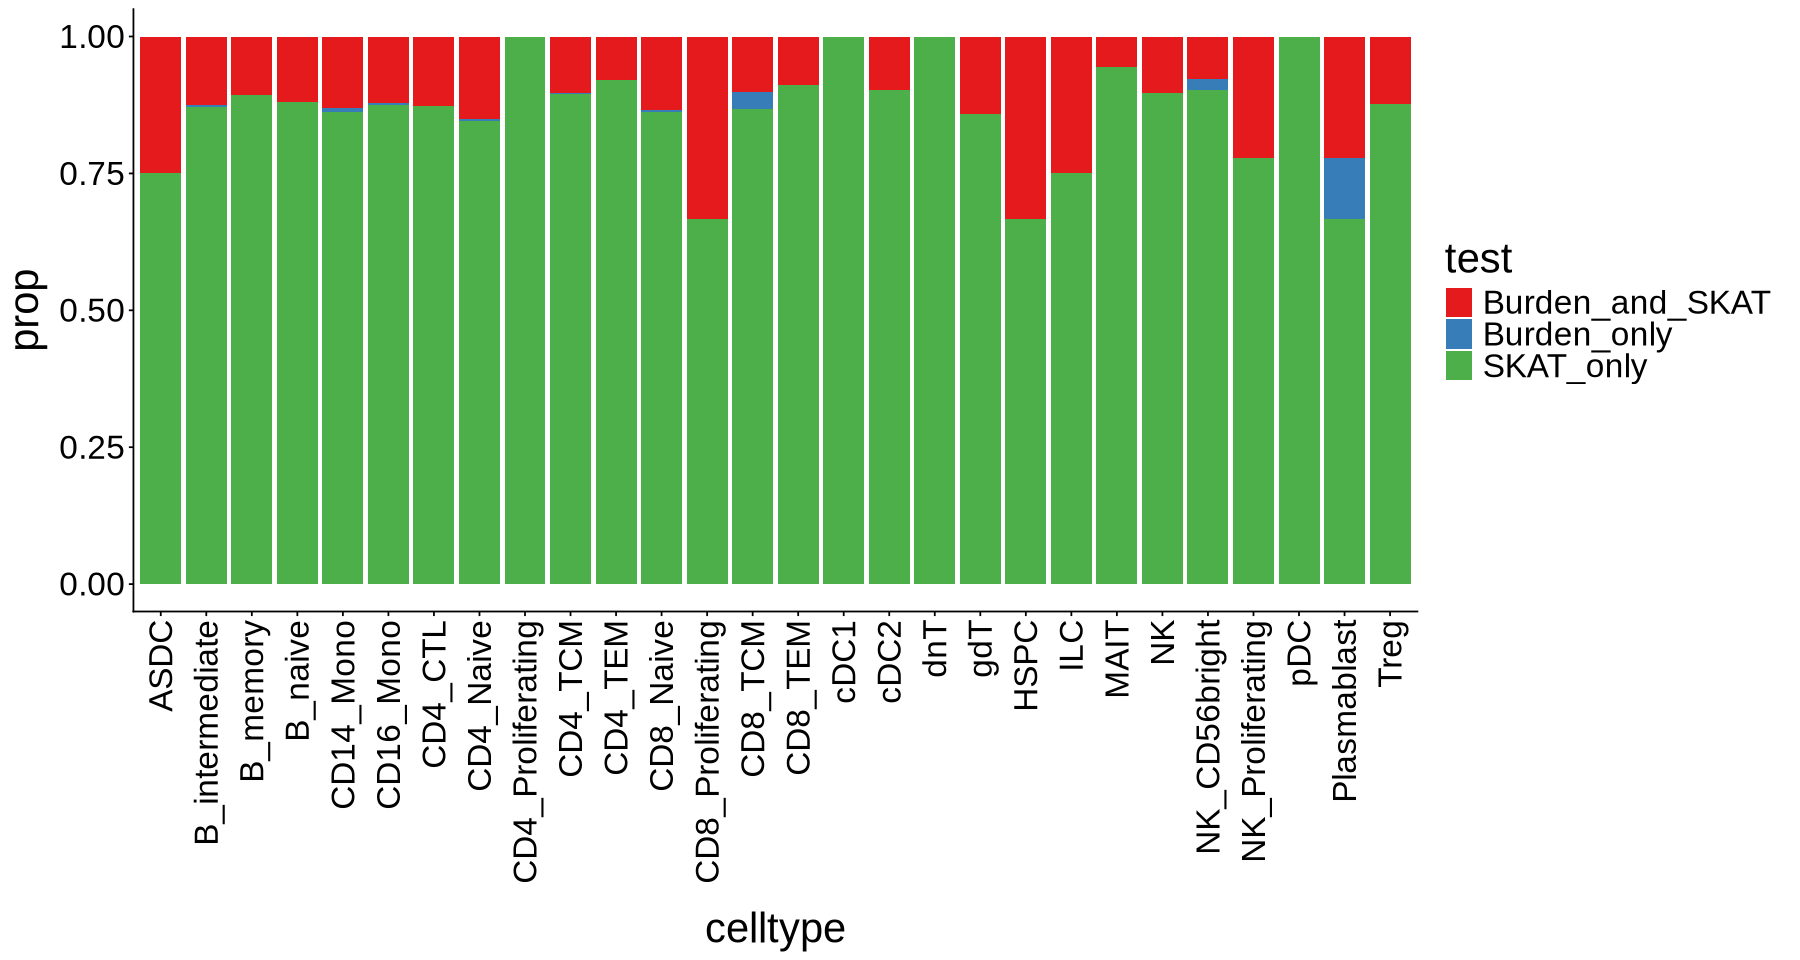

In [24]:
options(repr.plot.width = 15, repr.plot.height = 8)
p = ggplot(df_to_plot, aes(x=celltype,y=prop,fill=test)) + geom_bar(stat='identity')
p = p + scale_fill_brewer(palette = "Set1") + theme_classic() 
p = p + theme(text = element_text(size=25), axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1),)
p

In [ ]:
mydir = '/directflow/SCCGGroupShare/projects/anncuo/TenK10K_pilot/tenk10k/review_files/ct_mean_expression_files/'
df_all = read.csv(paste0(mydir,'mean_expression_all_genes_all_celltypes.csv'), row.names = 1)
df_all$mean_overall = rowMeans(df_all[,3:20])

In [78]:
df_list1 = list()
df_list2 = list()
for (celltype in celltypes){
    rare_set_file = paste0(saige_dir,celltype,'/',celltype,'_all_cis_rv_set_test_results.tsv')
    rare_set_df = as.data.frame(fread(rare_set_file))
    df = rare_set_df[rare_set_df$Group == "Cauchy",]
    df <- df[rowSums(is.na(df)) != ncol(df), ]
    for (i in 1:nrow(df)){
        df[i,'Pvalue_noACAT'] = get_CCT_pvalue(c(df[i,'Pvalue_Burden'], df[i,'Pvalue_SKAT']))
    }
    df$qvalue = qvalue(df$Pvalue_noACAT)$qvalues
    df$qvalue_Burden = qvalue(df$Pvalue_Burden)$qvalues
    df$qvalue_SKAT = qvalue(df$Pvalue_SKAT)$qvalues
    rare_egenes = df[df$qvalue<0.05,]$Region
    nonrare_egenes = df$Region[!(df$Region %in% rare_egenes)]
    burden_egenes = df[df$qvalue_Burden<0.05,]$Region
    burden_egenes = burden_egenes[burden_egenes %in% rare_egenes]
    skat_egenes = df[df$qvalue_SKAT<0.05,]$Region
    skat_egenes = skat_egenes[skat_egenes %in% rare_egenes]
    burden_only_egenes = burden_egenes[!(burden_egenes %in% skat_egenes)]
    burden_and_skat_egenes = skat_egenes[skat_egenes %in% burden_egenes]
    skat_only_egenes = skat_egenes[!(skat_egenes %in% burden_egenes)]
    df_cur1 = data.frame(celltype = celltype,
                         test = c('Burden_only','Burden_and_SKAT','SKAT_only'),
                         mean_overall = c(mean(df_all[df_all$gene %in% burden_only_egenes,'mean_overall']), 
                                        mean(df_all[df_all$gene %in% burden_and_skat_egenes,'mean_overall']), 
                                        mean(df_all[df_all$gene %in% skat_only_egenes,'mean_overall'])))
    df_list1[[celltype]] = df_cur1
    df_cur2 = data.frame(celltype = celltype,
                        test =  c('rare eGene','non rare eGene'),
                         mean_overall = c(mean(df_all[df_all$gene %in% rare_egenes,'mean_overall']), 
                                        mean(df_all[df_all$gene %in% nonrare_egenes,'mean_overall'])))
    df_list2[[celltype]] = df_cur2
}
df_to_plot1 = rbindlist(df_list1)
nrow(df_to_plot1)
head(df_to_plot1,2)
df_to_plot2 = rbindlist(df_list2)
nrow(df_to_plot2)
head(df_to_plot2,2)

[1] 84

celltype,test,mean_overall
<chr>,<chr>,<dbl>
ASDC,Burden_only,0.04497864
ASDC,Burden_and_SKAT,0.45823738


[1] 56

celltype,test,mean_overall
<chr>,<chr>,<dbl>
ASDC,rare eGene,0.8024160
ASDC,non rare eGene,0.6487655


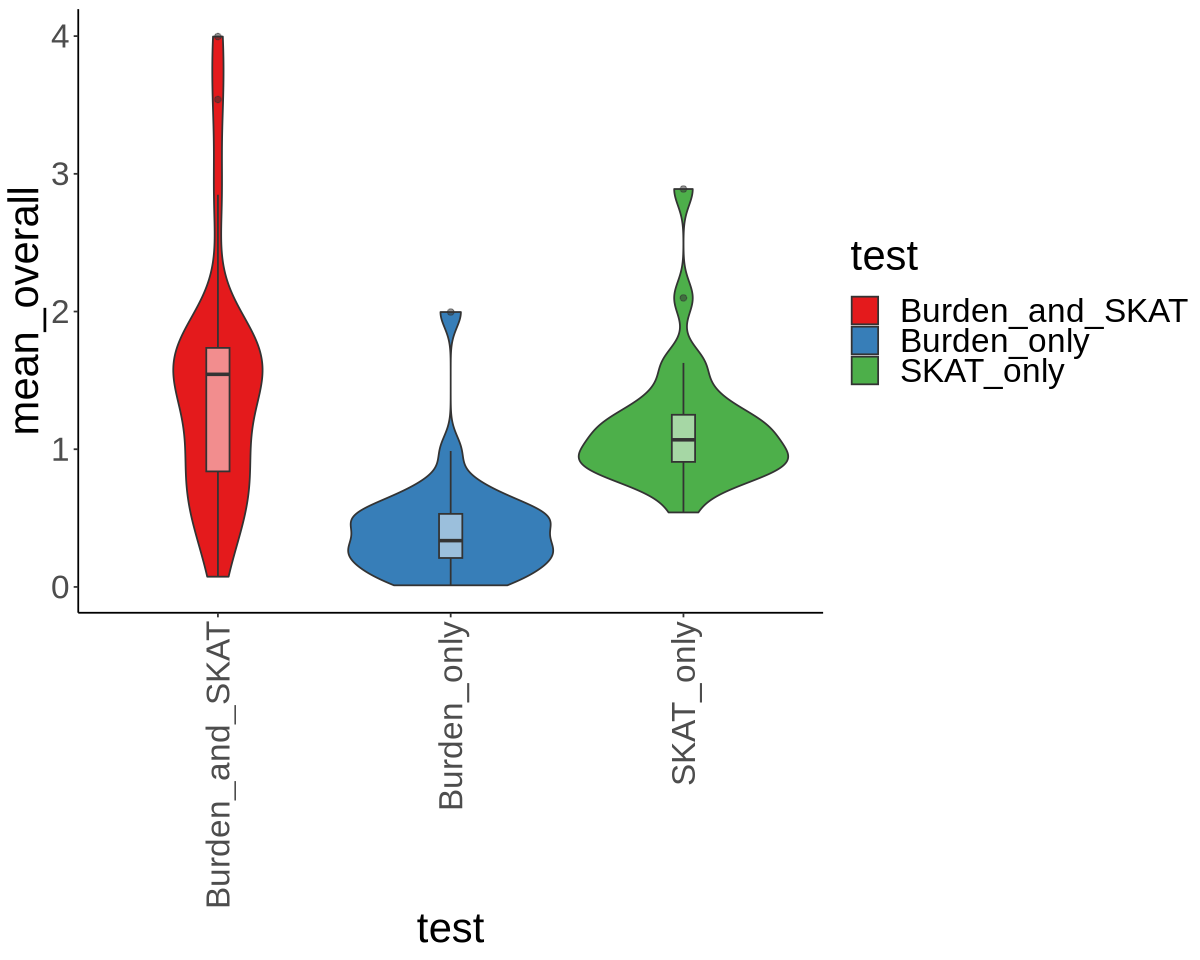

In [85]:
options(repr.plot.width = 10, repr.plot.height = 8)
p = ggplot(df_to_plot1[df_to_plot1$mean_overall<5,], aes(x=test,y=mean_overall,fill=test)) + geom_violin() 
p = p + geom_boxplot(width=0.1, fill='white', alpha=0.5)
p = p + scale_fill_brewer(palette = "Set1") + theme_classic() 
p = p + theme(text = element_text(size=25), axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1),)
p

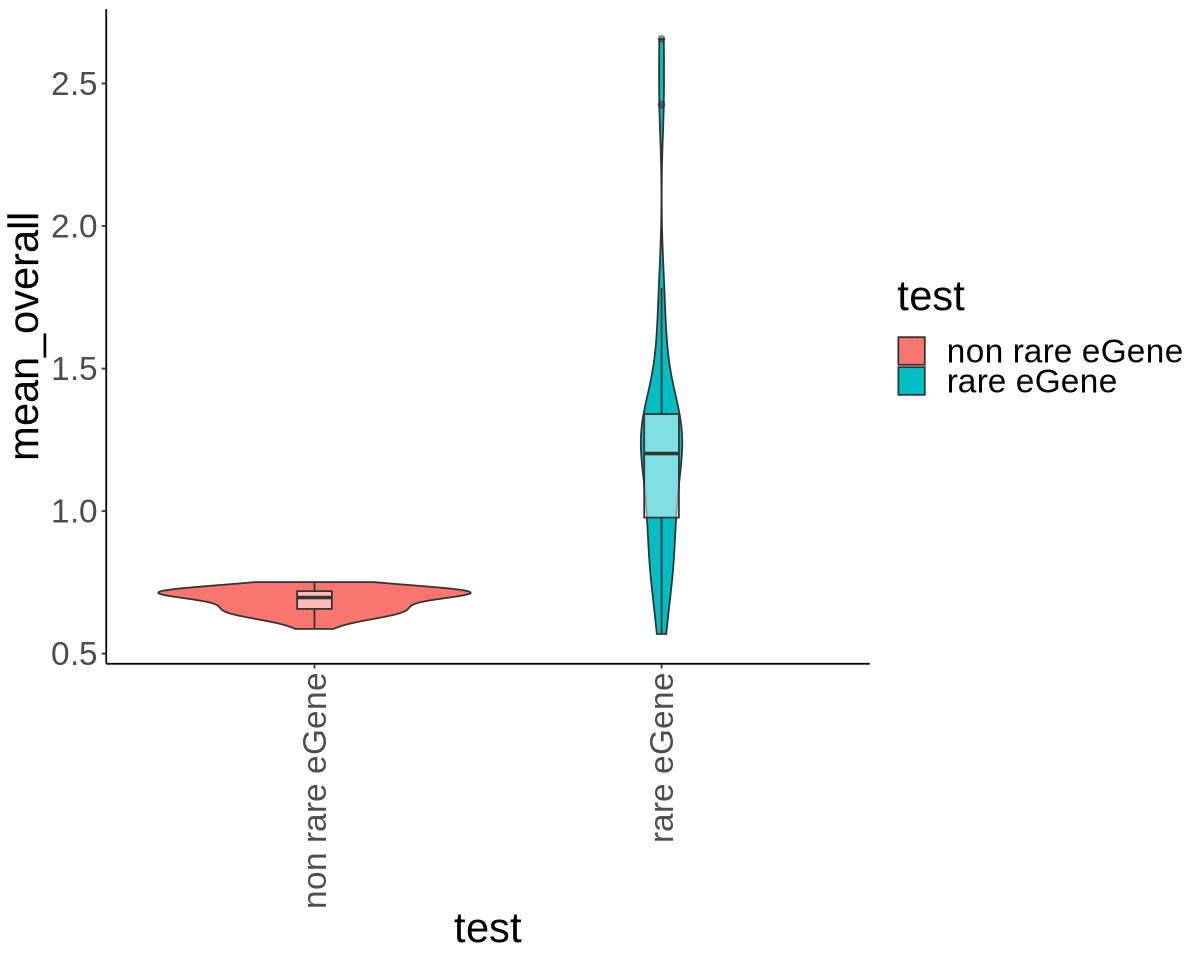

In [87]:
options(repr.plot.width = 10, repr.plot.height = 8)
p = ggplot(df_to_plot2, aes(x=test,y=mean_overall,fill=test)) + geom_violin() 
p = p + geom_boxplot(width=0.1, fill='white', alpha=0.5)
p = p + theme_classic() 
p = p + theme(text = element_text(size=25), axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1),)
p

In [ ]:
# can we test whether rare eGenes (or at least burden ones) are longer on average 

In [1]:
gencode_text_file = '/directflow/SCCGGroupShare/projects/anncuo/reference_data/gencode.v44.basic.annotation_df.txt'
gene_info = read.csv(gencode_text_file)
gene_info$gene = gsub("\\..*","",gene_info$gene_id)
head(gene_info,2)

,chr,source,type,start,end,score,strand,phase,attributes,gene_id,gene_name,gene_type,gene
,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,chr1,HAVANA,gene,11869,14409,.,+,.,"gene_id ""ENSG00000290825.1""; gene_type ""lncRNA""; gene_name ""DDX11L2""; level 2; tag ""overlaps_pseudogene"";",ENSG00000290825.1,DDX11L2,lncRNA,ENSG00000290825
2,chr1,HAVANA,gene,12010,13670,.,+,.,"gene_id ""ENSG00000223972.6""; gene_type ""transcribed_unprocessed_pseudogene""; gene_name ""DDX11L1""; level 2; hgnc_id ""HGNC:37102""; havana_gene ""OTTHUMG00000000961.2"";",ENSG00000223972.6,DDX11L1,transcribed_unprocessed_pseudogene,ENSG00000223972


In [2]:
gene_info$length = gene_info$end - gene_info$start
head(gene_info,2)

,chr,source,type,start,end,score,strand,phase,attributes,gene_id,gene_name,gene_type,gene,length
,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
1,chr1,HAVANA,gene,11869,14409,.,+,.,"gene_id ""ENSG00000290825.1""; gene_type ""lncRNA""; gene_name ""DDX11L2""; level 2; tag ""overlaps_pseudogene"";",ENSG00000290825.1,DDX11L2,lncRNA,ENSG00000290825,2540
2,chr1,HAVANA,gene,12010,13670,.,+,.,"gene_id ""ENSG00000223972.6""; gene_type ""transcribed_unprocessed_pseudogene""; gene_name ""DDX11L1""; level 2; hgnc_id ""HGNC:37102""; havana_gene ""OTTHUMG00000000961.2"";",ENSG00000223972.6,DDX11L1,transcribed_unprocessed_pseudogene,ENSG00000223972,1660


In [22]:
df_list1 = list()
df_list2 = list()
for (celltype in celltypes){
    rare_set_file = paste0(saige_dir,celltype,'/',celltype,'_all_cis_rv_set_test_results.tsv')
    rare_set_df = as.data.frame(fread(rare_set_file))
    df = rare_set_df[rare_set_df$Group == "Cauchy",]
    df <- df[rowSums(is.na(df)) != ncol(df), ]
    for (i in 1:nrow(df)){
        df[i,'Pvalue_noACAT'] = get_CCT_pvalue(c(df[i,'Pvalue_Burden'], df[i,'Pvalue_SKAT']))
    }
    df$qvalue = qvalue(df$Pvalue_noACAT)$qvalues
    df$qvalue_Burden = qvalue(df$Pvalue_Burden)$qvalues
    df$qvalue_SKAT = qvalue(df$Pvalue_SKAT)$qvalues
    rare_egenes = df[df$qvalue<0.05,]$Region
    nonrare_egenes = df$Region[!(df$Region %in% rare_egenes)]
    burden_egenes = df[df$qvalue_Burden<0.05,]$Region
    burden_egenes = burden_egenes[burden_egenes %in% rare_egenes]
    skat_egenes = df[df$qvalue_SKAT<0.05,]$Region
    skat_egenes = skat_egenes[skat_egenes %in% rare_egenes]
    burden_only_egenes = burden_egenes[!(burden_egenes %in% skat_egenes)]
    burden_and_skat_egenes = skat_egenes[skat_egenes %in% burden_egenes]
    skat_only_egenes = skat_egenes[!(skat_egenes %in% burden_egenes)]
    df_cur1 = data.frame(celltype = celltype,
                         test = c('Burden_only','Burden_and_SKAT','SKAT_only'),
                         length = c(mean(gene_info[gene_info$gene %in% burden_only_egenes,'length']), 
                                        mean(gene_info[gene_info$gene %in% burden_and_skat_egenes,'length']), 
                                        mean(gene_info[gene_info$gene %in% skat_only_egenes,'length'])))
    df_list1[[celltype]] = df_cur1
    df_cur2 = data.frame(celltype = celltype,
                        test =  c('rare eGene','non rare eGene'),
                         length = c(mean(gene_info[gene_info$gene %in% rare_egenes,'length']), 
                                        mean(gene_info[gene_info$gene %in% nonrare_egenes,'length'])))
    df_list2[[celltype]] = df_cur2
}
df_to_plot1 = rbindlist(df_list1)
nrow(df_to_plot1)
head(df_to_plot1,2)
df_to_plot2 = rbindlist(df_list2)
nrow(df_to_plot2)
head(df_to_plot2,2)

[1] 84

celltype,test,length
<chr>,<chr>,<dbl>
ASDC,Burden_only,9274.0
ASDC,Burden_and_SKAT,141926.2


[1] 56

celltype,test,length
<chr>,<chr>,<dbl>
ASDC,rare eGene,154467.93
ASDC,non rare eGene,71205.24


Warning message:
“Removed 1 row containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”


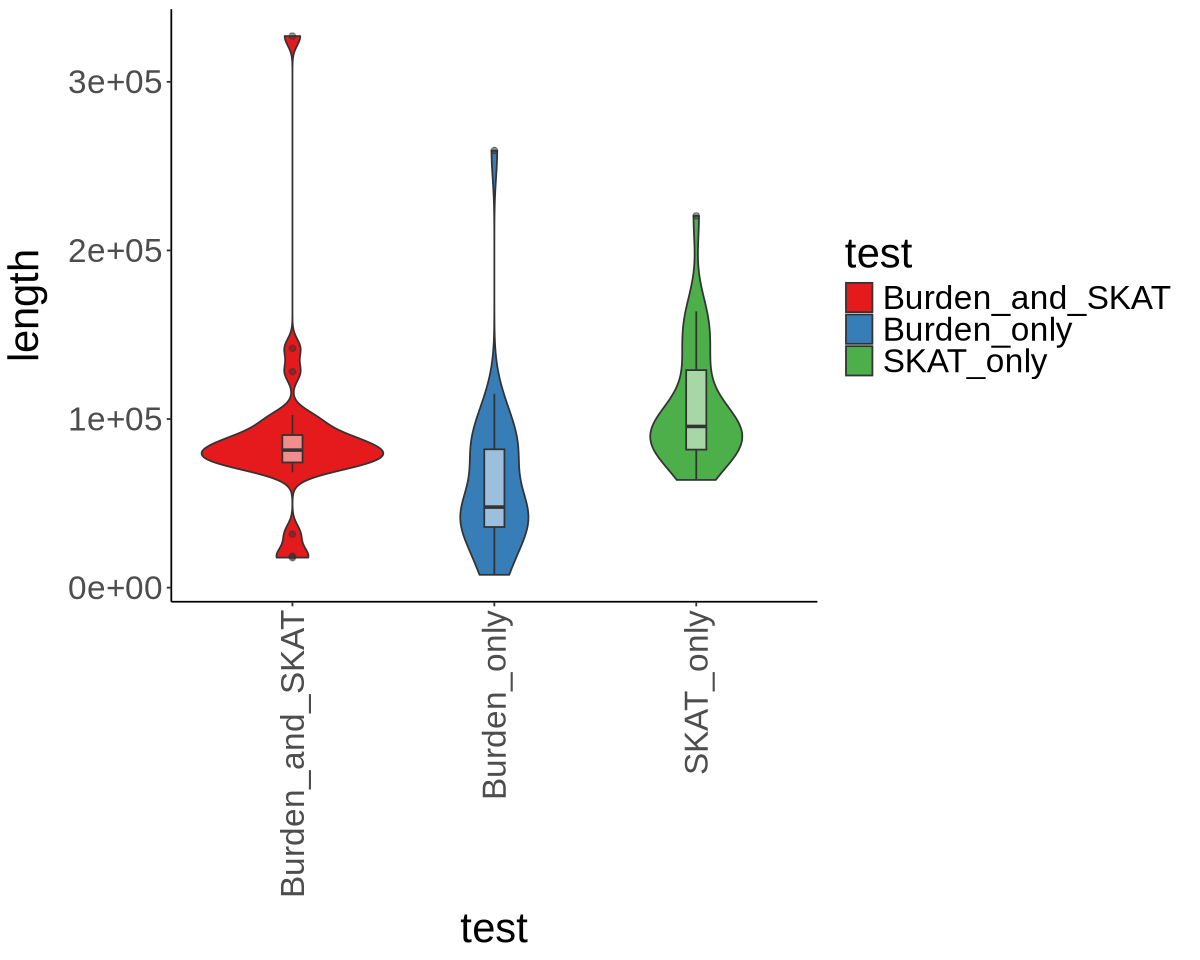

In [23]:
options(repr.plot.width = 10, repr.plot.height = 8)
p = ggplot(df_to_plot1, aes(x=test,y=length,fill=test)) + geom_violin() 
p = p + geom_boxplot(width=0.1, fill='white', alpha=0.5)
p = p + scale_fill_brewer(palette = "Set1") + theme_classic() 
p = p + theme(text = element_text(size=25), axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1),)
p

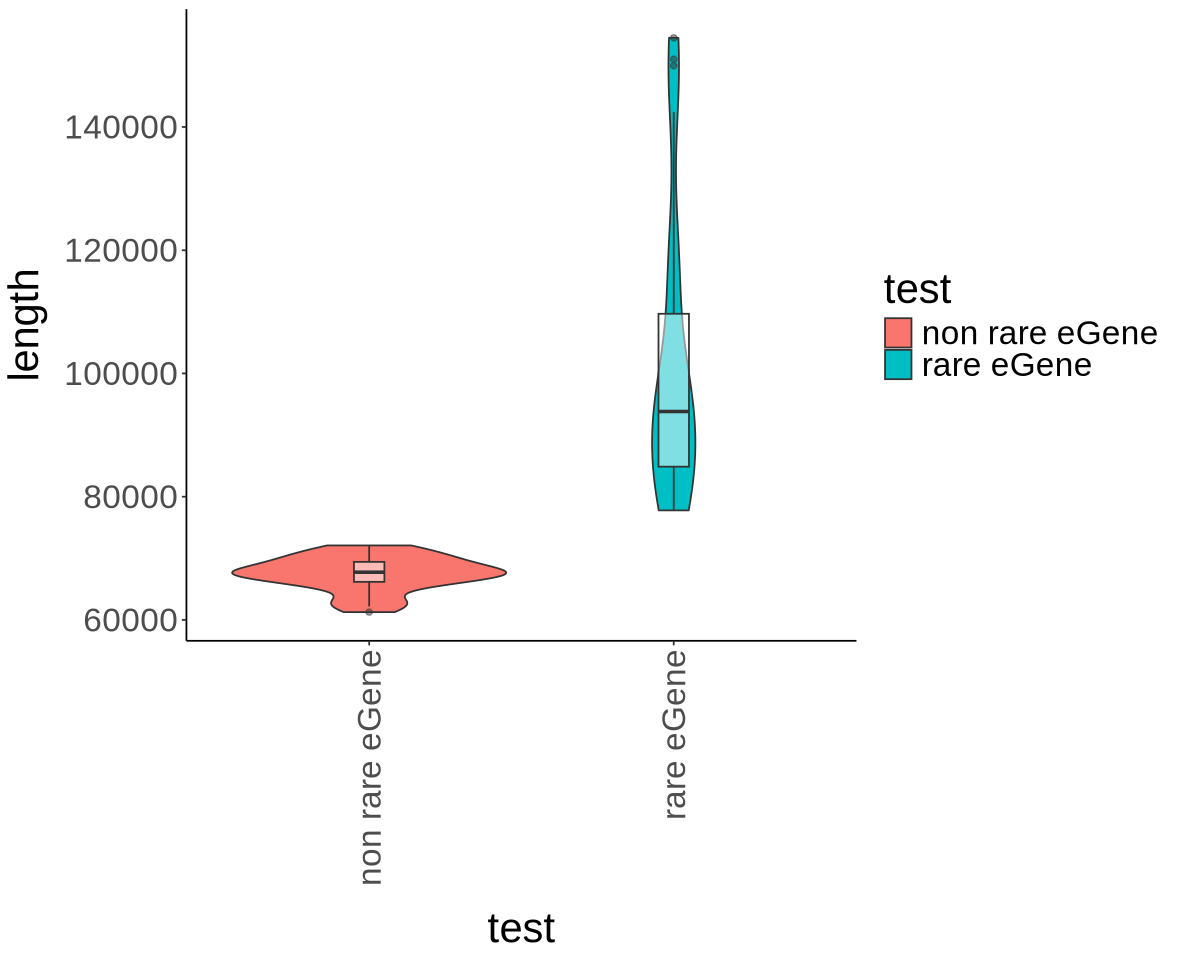

In [24]:
options(repr.plot.width = 10, repr.plot.height = 8)
p = ggplot(df_to_plot2, aes(x=test,y=length,fill=test)) + geom_violin() 
p = p + geom_boxplot(width=0.1, fill='white', alpha=0.5)
p = p + theme_classic() 
p = p + theme(text = element_text(size=25), axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1),)
p

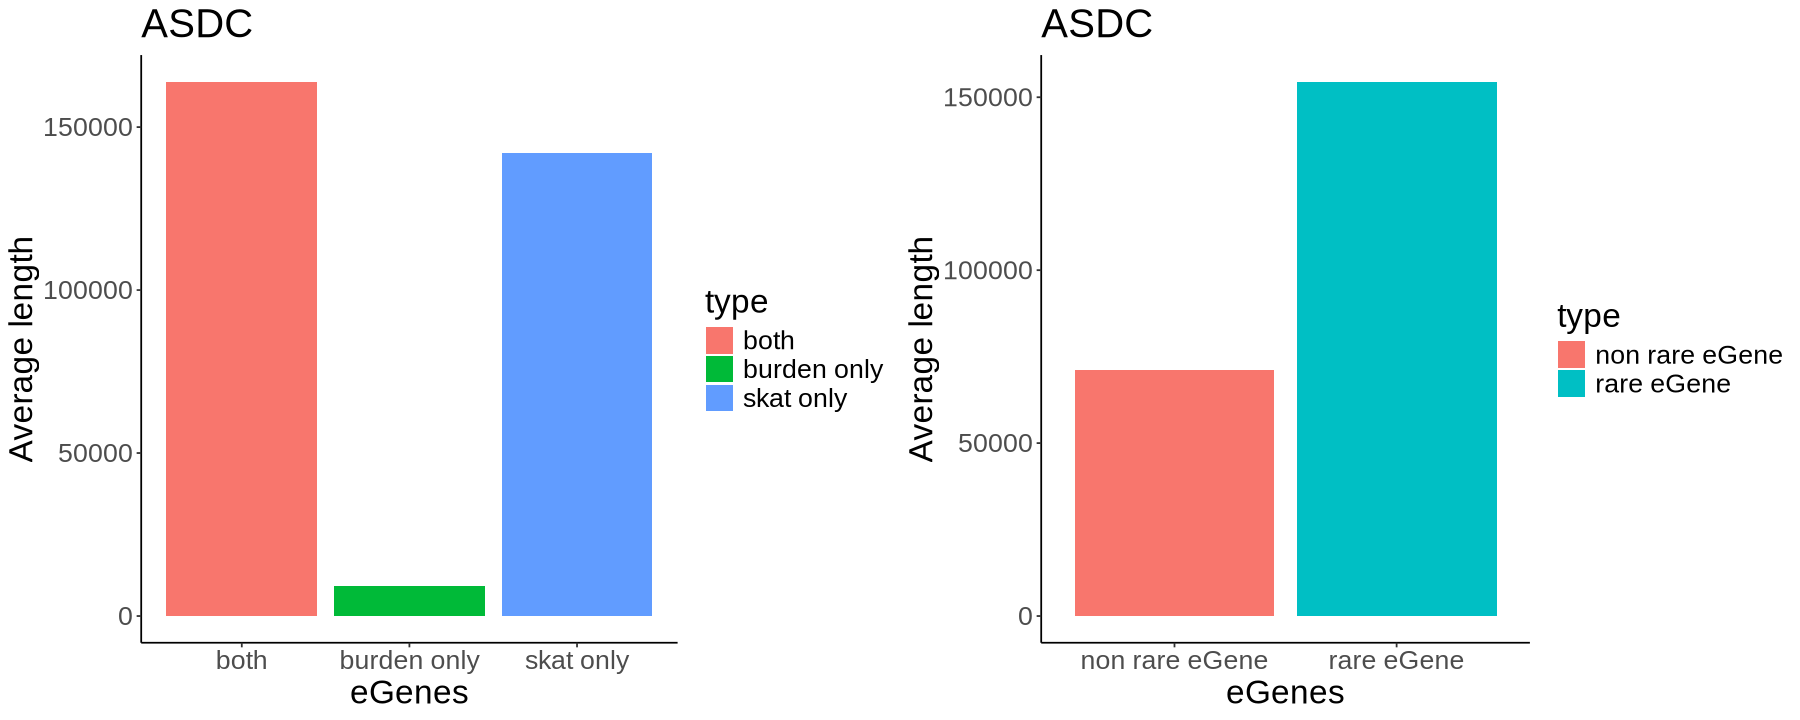

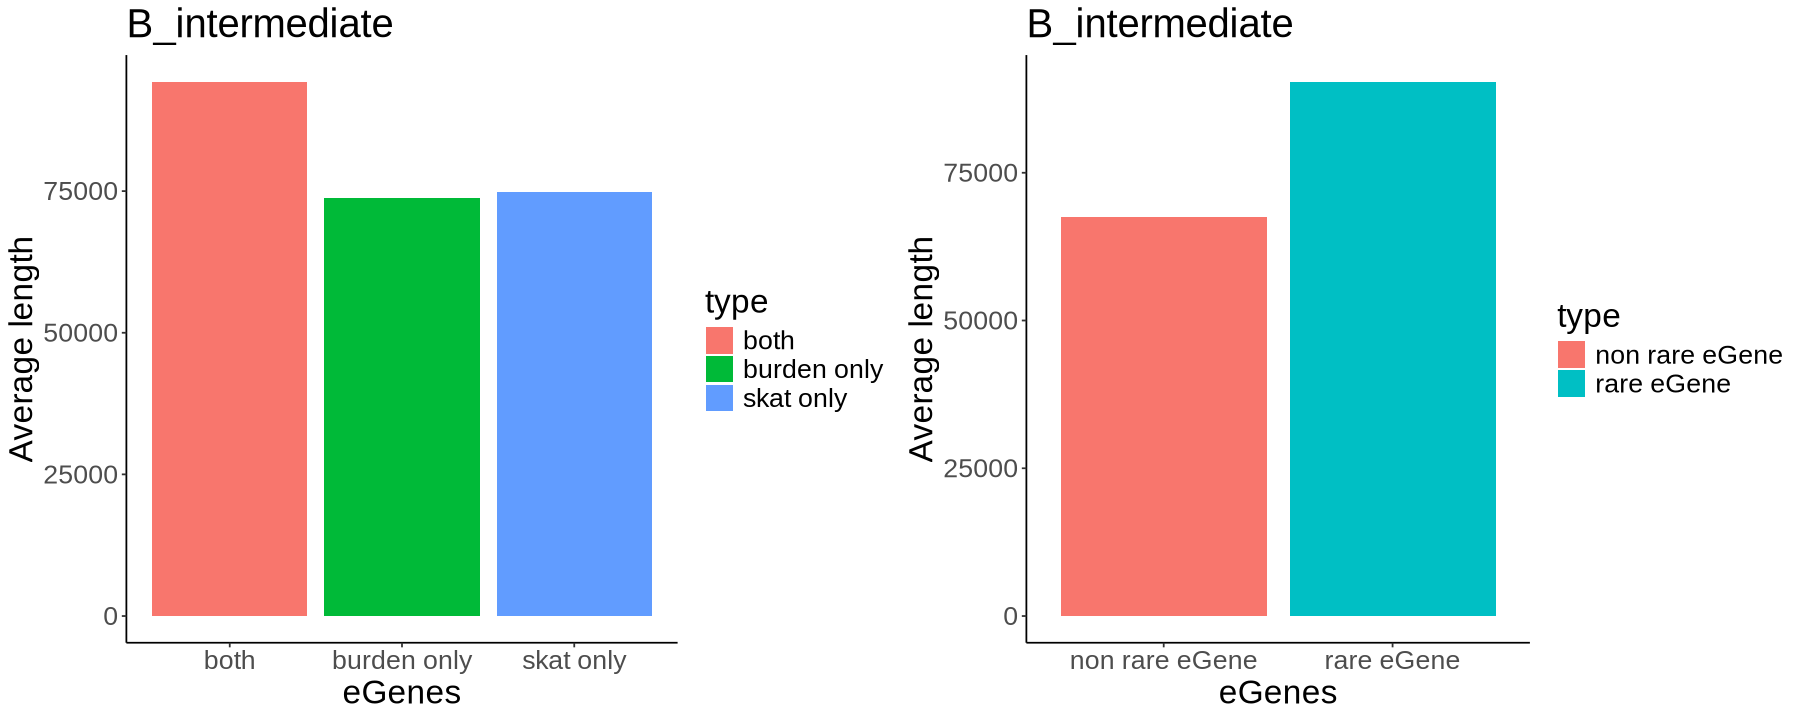

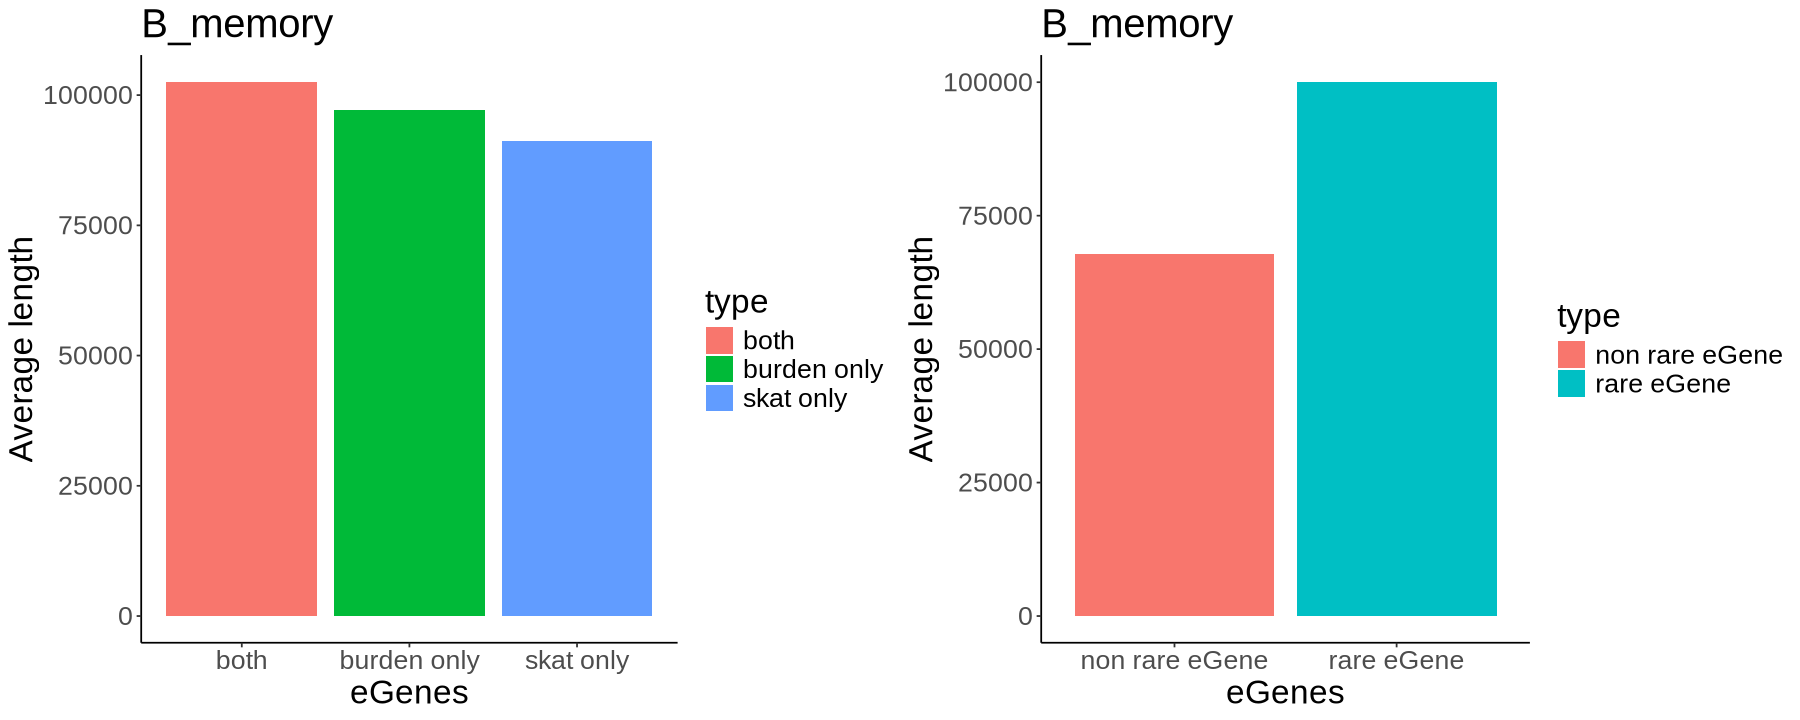

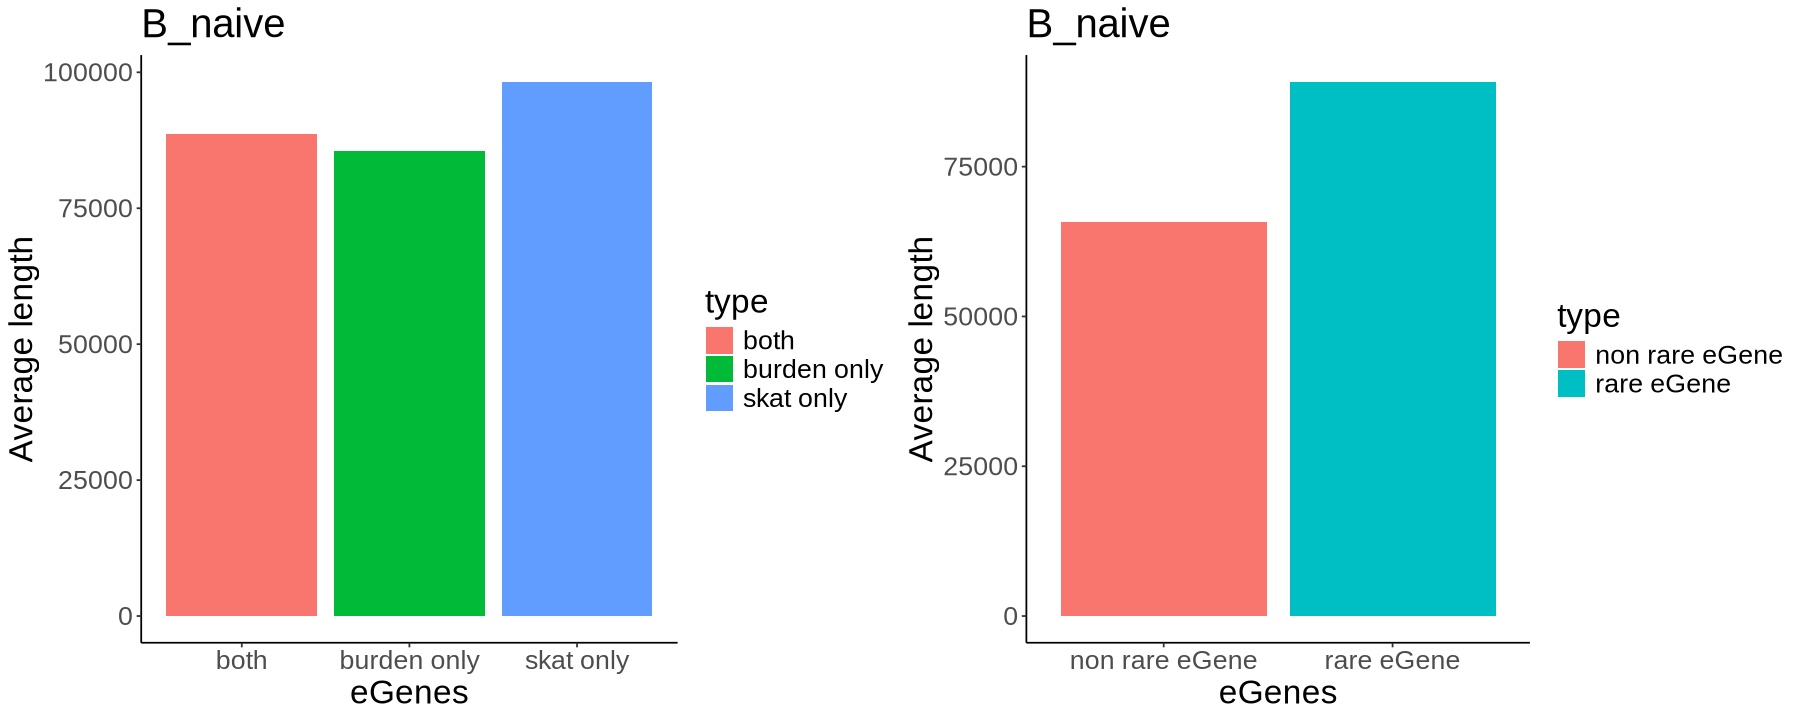

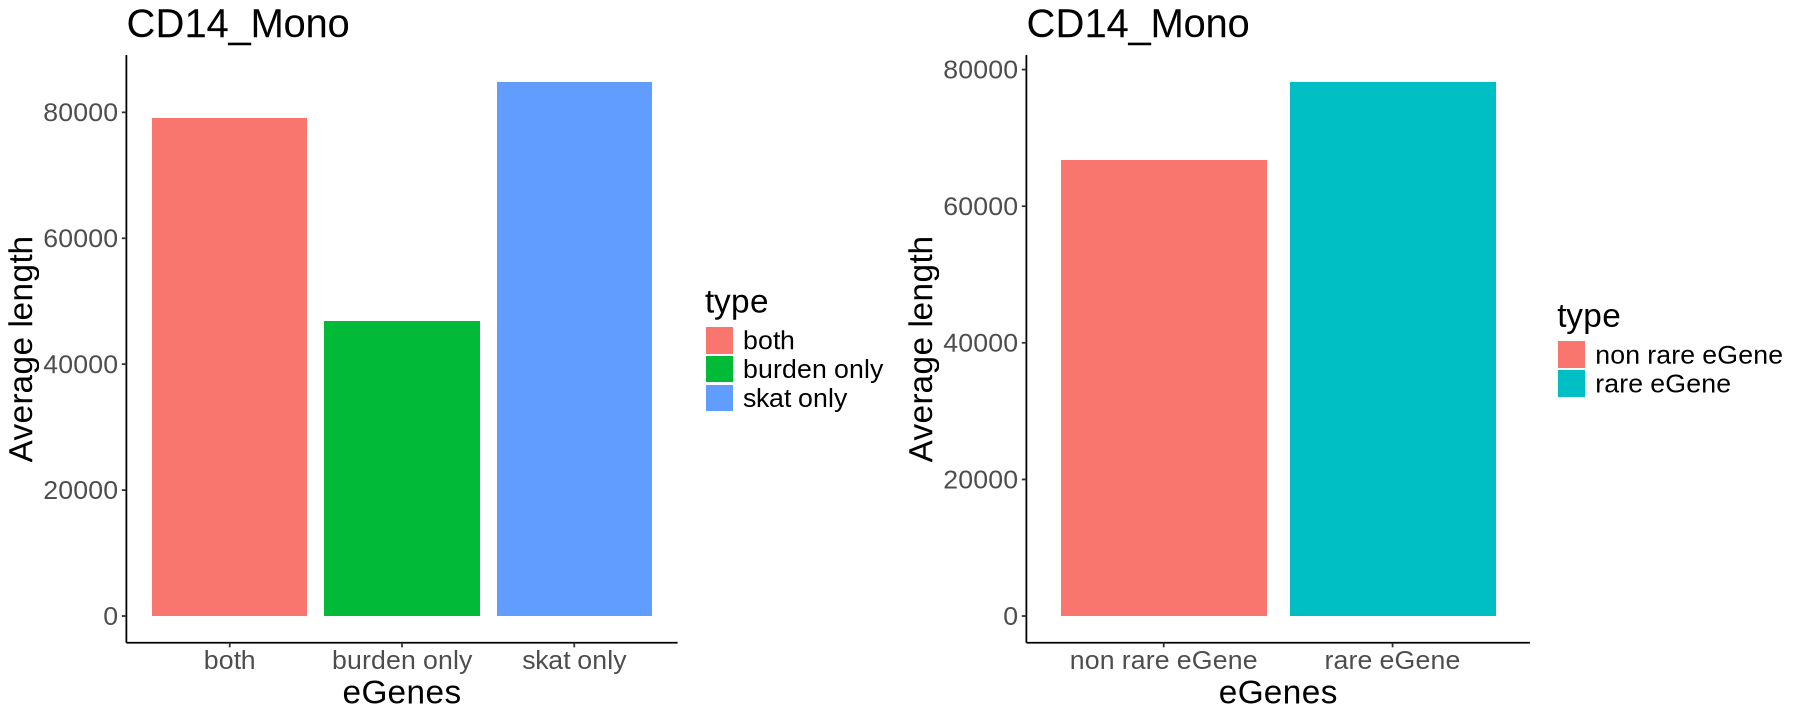

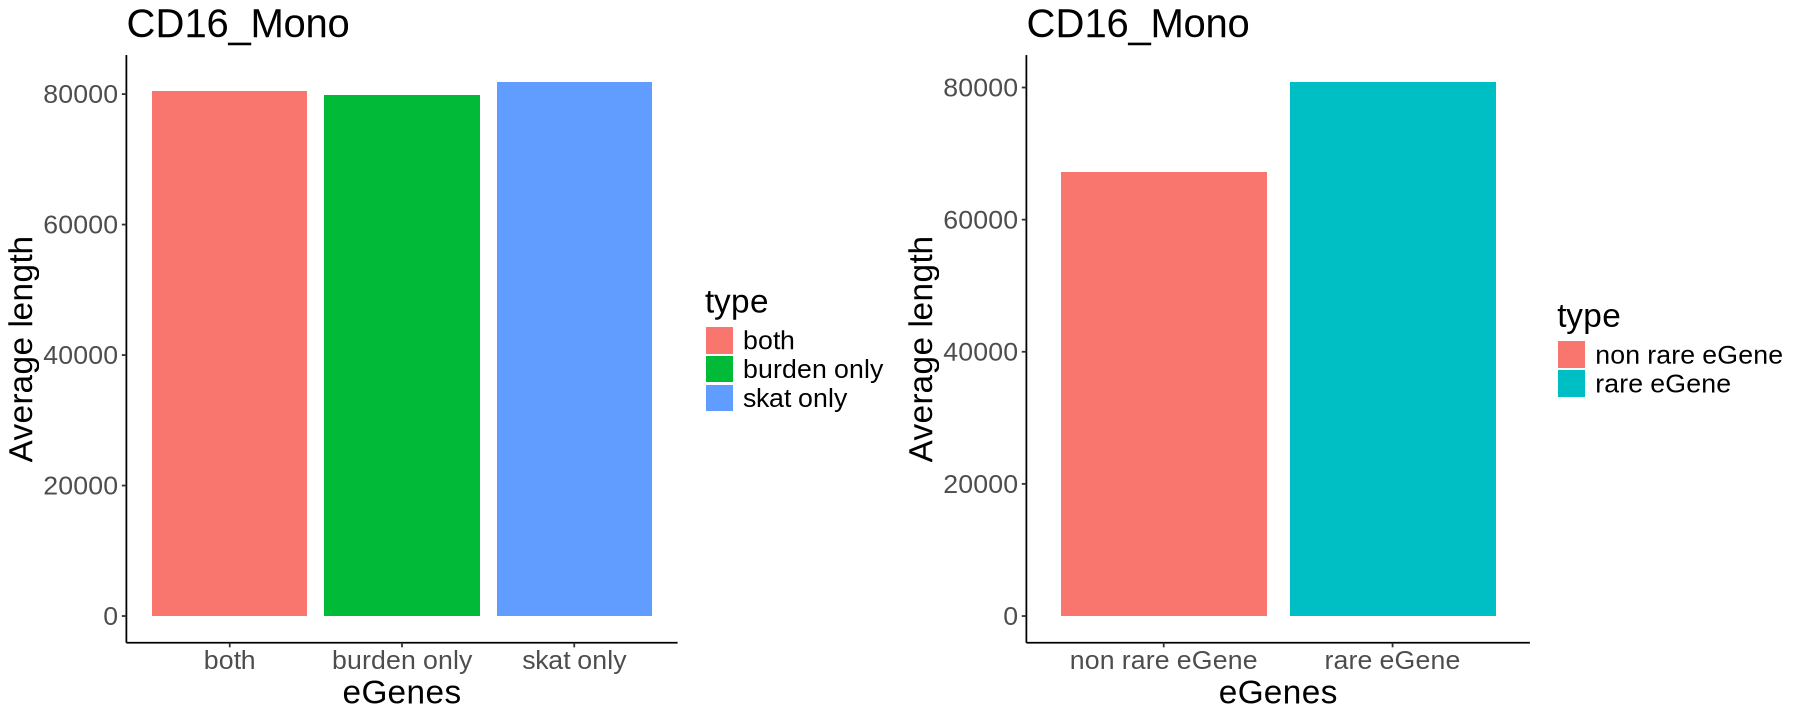

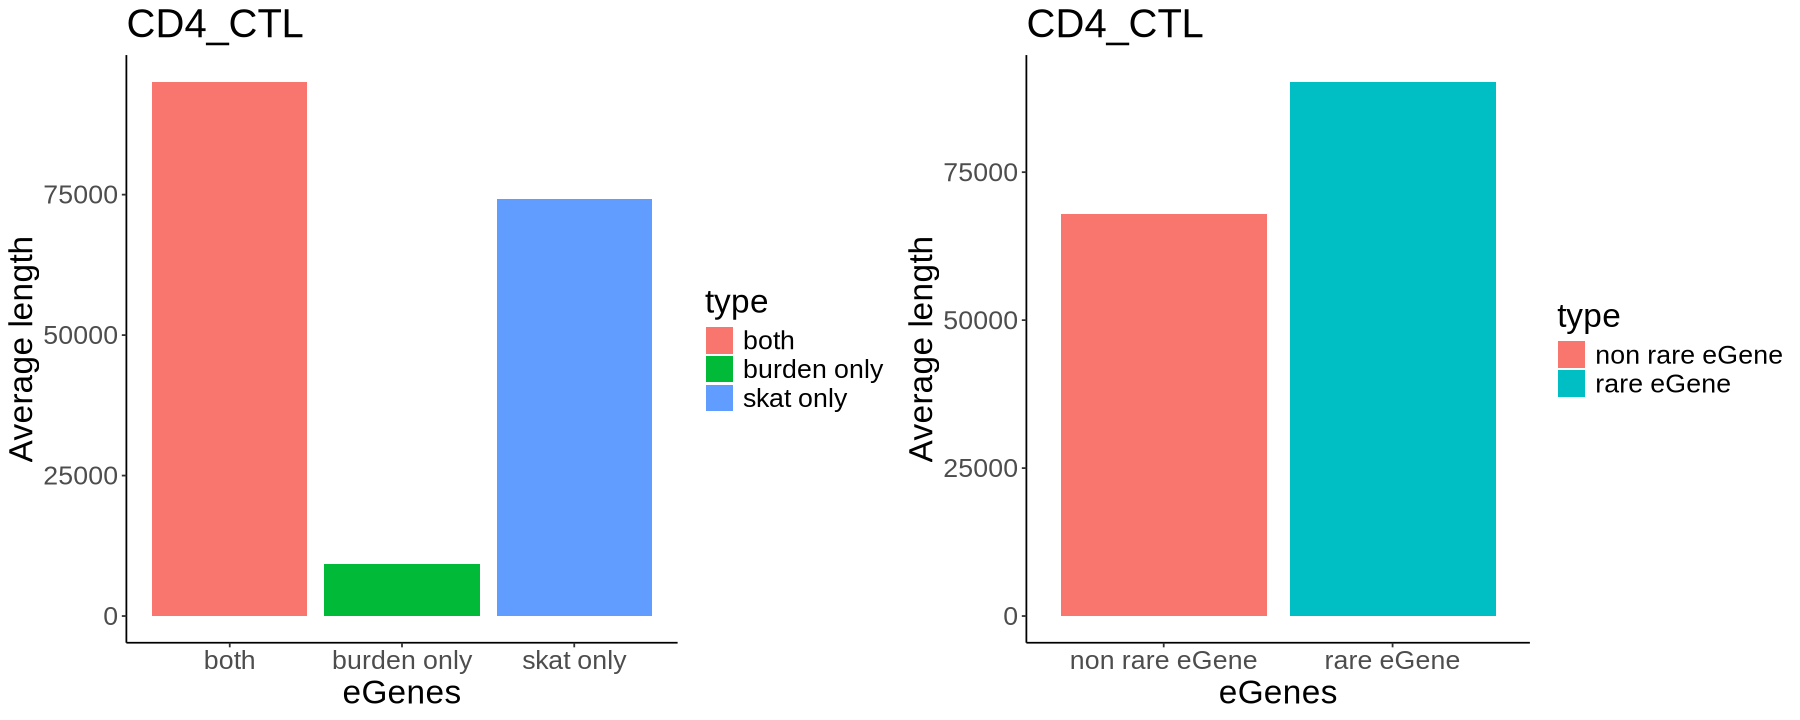

In [ ]:
options(repr.plot.width = 15, repr.plot.height = 6)
for (celltype in celltypes){
    rare_set_file = paste0(saige_dir,celltype,'/',celltype,'_all_cis_rv_set_test_results.tsv')
    df = as.data.frame(fread(rare_set_file))
    df = df[df$Group == "Cauchy",]
    df$celltype = celltype
    for (i in 1:nrow(df)){
        df[i,'Pvalue_noACAT'] = get_CCT_pvalue(c(df[i,'Pvalue_Burden'], df[i,'Pvalue_SKAT']))
    }
    df$qvalue = qvalue(df$Pvalue_noACAT)$qvalues
    rare_egenes = df[df$qvalue<0.05,]$Region
    nonrare_egenes = df$Region[!(df$Region %in% rare_egenes)]
    df$qvalue_Burden = qvalue(df$Pvalue_Burden)$qvalues
    df$qvalue_SKAT = qvalue(df$Pvalue_SKAT)$qvalues
    burden_egenes = df[df$qvalue_Burden<0.05,]$Region
    burden_egenes = burden_egenes[burden_egenes %in% rare_egenes]
    skat_egenes = df[df$qvalue_SKAT<0.05,]$Region
    skat_egenes = skat_egenes[skat_egenes %in% rare_egenes]
    burden_only_egenes = burden_egenes[!(burden_egenes %in% skat_egenes)]
    burden_and_skat_egenes = skat_egenes[skat_egenes %in% burden_egenes]
    skat_only_egenes = skat_egenes[!(skat_egenes %in% burden_egenes)]
    df_to_plot = data.frame(type = c('burden only','skat only','both'),
                       length = c(mean(gene_info[gene_info$gene %in% burden_only_egenes,'length']), 
                                        mean(gene_info[gene_info$gene %in% burden_and_skat_egenes,'length']), 
                                        mean(gene_info[gene_info$gene %in% skat_only_egenes,'length'])))
    p = ggplot(df_to_plot, aes(fill=type, y=length, x=type)) 
    # p = p + scale_fill_manual(values=c('darkblue','cornflowerblue'))
    p = p + geom_bar(stat="identity") 
    p = p + theme_classic() + theme(text = element_text(size=20))
    p1 = p + xlab('eGenes') + ylab('Average length') + ggtitle(celltype)
    df_to_plot = data.frame(type = c('rare eGene','non rare eGene'),
                       mean_overall = c(mean(gene_info[gene_info$gene %in% rare_egenes,'length']), 
                                        mean(gene_info[gene_info$gene %in% nonrare_egenes,'length'])))
    p = ggplot(df_to_plot, aes(fill=type, y=mean_overall, x=type)) 
    p = p + geom_bar(stat="identity") 
    p = p + theme_classic() + theme(text = element_text(size=20))
    p2 = p + xlab('eGenes') + ylab('Average length') + ggtitle(celltype)
    print(plot_grid(p1, p2))
}